In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("✅ All imports successful!")

✅ All imports successful!


In [ ]:
# ⚠️ 3 things changed from Strategy A evaluation:
# 1. PROCESSED_PATH → processed_segmented
# 2. MODEL loaded → best_model_B_segmented.h5
# 3. STRATEGY label → B_segmented

PROCESSED_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\processed_segmented"
MODEL_PATH     = r"D:\Development\8th Sem Project\TomatoClassification\models"
IMAGE_SIZE     = (224, 224)
BATCH_SIZE     = 32
STRATEGY       = "B_segmented"

# Load Strategy B model
model = load_model(os.path.join(MODEL_PATH, 'best_model_B_segmented.h5'))

print(f"✅ Strategy {STRATEGY} model loaded!")
print(f"📊 Input shape  : {model.input_shape}")
print(f"📊 Output shape : {model.output_shape}")

✅ Strategy B_segmented model loaded!
📊 Input shape  : (None, 224, 224, 3)
📊 Output shape : (None, 10)


In [3]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get class names
class_names = list(test_generator.class_indices.keys())
class_names_short = [c.replace("Tomato___", "").replace("_", " ")
                     for c in class_names]

print(f"✅ Test data loaded!")
print(f"🧪 Total test images : {test_generator.samples}")
print(f"📋 Classes           : {len(class_names)}")
print(f"\nClass names:")
for i, name in enumerate(class_names_short):
    print(f"  {i:2d} → {name}")

Found 1399 images belonging to 10 classes.
✅ Test data loaded!
🧪 Total test images : 1399
📋 Classes           : 10

Class names:
   0 → Bacterial spot
   1 → Early blight
   2 → Late blight
   3 → Leaf Mold
   4 → Septoria leaf spot
   5 → Spider mites Two-spotted spider mite
   6 → Target Spot
   7 → Tomato Yellow Leaf Curl Virus
   8 → Tomato mosaic virus
   9 → healthy


In [4]:
print(f"🔄 Evaluating Strategy {STRATEGY} on test set...\n")

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n{'='*50}")
print(f"📊 Strategy {STRATEGY} — Test Results")
print(f"{'='*50}")
print(f"✅ Test Accuracy : {test_accuracy:.2%}")
print(f"📉 Test Loss     : {test_loss:.4f}")
print(f"{'='*50}")

# Comparison with Strategy A
print(f"\n📈 Strategy Comparison So Far:")
print(f"  Strategy A (Color only)     : 89.06%")
print(f"  Strategy B (Segmented only) : {test_accuracy:.2%}")
print(f"  Strategy C (Mixed 50/50)    : pending ⬜")
print(f"  Strategy D (Fine-tuned)     : pending ⬜")
print(f"\n  A vs B Difference: {(test_accuracy - 0.8906)*100:+.2f}%")

🔄 Evaluating Strategy B_segmented on test set...

44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 762ms/step - accuracy: 0.8613 - loss: 0.4064

📊 Strategy B_segmented — Test Results
✅ Test Accuracy : 86.13%
📉 Test Loss     : 0.4064

📈 Strategy Comparison So Far:
  Strategy A (Color only)     : 89.06%
  Strategy B (Segmented only) : 86.13%
  Strategy C (Mixed 50/50)    : pending ⬜
  Strategy D (Fine-tuned)     : pending ⬜

  A vs B Difference: -2.93%


🔄 Generating predictions...
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 621ms/step


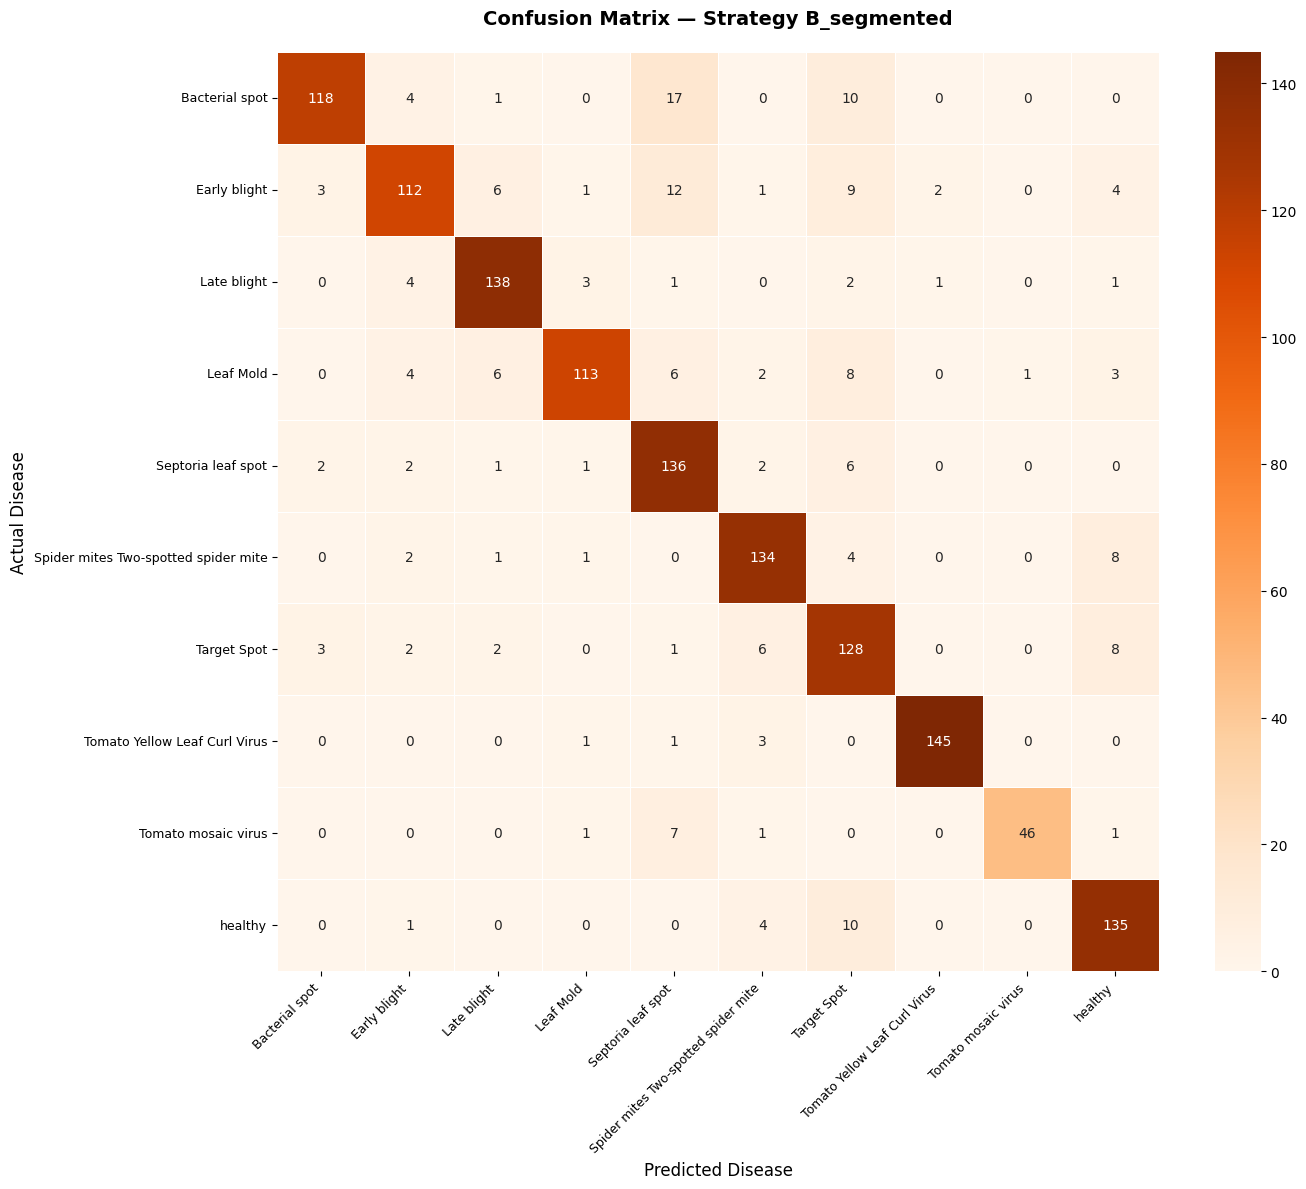

✅ Confusion matrix saved!


In [5]:
print("🔄 Generating predictions...")

predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',        # ← different color from Strategy A (Blues)
    xticklabels=class_names_short,
    yticklabels=class_names_short,
    linewidths=0.5
)
plt.title(f'Confusion Matrix — Strategy {STRATEGY}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

os.makedirs("../outputs", exist_ok=True)
plt.savefig(f"../outputs/confusion_matrix_{STRATEGY}.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Confusion matrix saved!")

📋 Classification Report — Strategy B_segmented

                                      precision    recall  f1-score   support

                      Bacterial spot      0.937     0.787     0.855       150
                        Early blight      0.855     0.747     0.797       150
                         Late blight      0.890     0.920     0.905       150
                           Leaf Mold      0.934     0.790     0.856       143
                  Septoria leaf spot      0.751     0.907     0.822       150
Spider mites Two-spotted spider mite      0.876     0.893     0.884       150
                         Target Spot      0.723     0.853     0.783       150
       Tomato Yellow Leaf Curl Virus      0.980     0.967     0.973       150
                 Tomato mosaic virus      0.979     0.821     0.893        56
                             healthy      0.844     0.900     0.871       150

                            accuracy                          0.861      1399
              

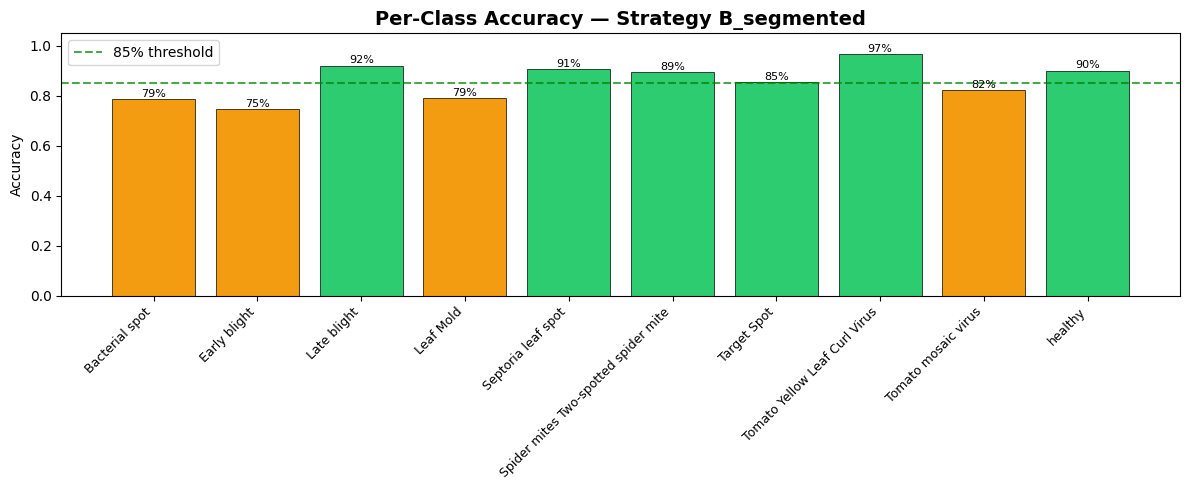

✅ Per-class chart saved!


In [6]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names_short,
    digits=3
)

print(f"📋 Classification Report — Strategy {STRATEGY}\n")
print(report)

# Visual bar chart
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if acc >= 0.85 else '#f39c12' if acc >= 0.70
          else '#e74c3c' for acc in per_class_accuracy]

bars = plt.bar(class_names_short, per_class_accuracy,
               color=colors, edgecolor='black', linewidth=0.5)

plt.axhline(y=0.85, color='green', linestyle='--',
            alpha=0.7, label='85% threshold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Accuracy")
plt.title(f"Per-Class Accuracy — Strategy {STRATEGY}",
          fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)
plt.legend()

for bar, acc in zip(bars, per_class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{acc:.0%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"../outputs/per_class_accuracy_{STRATEGY}.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Per-class chart saved!")

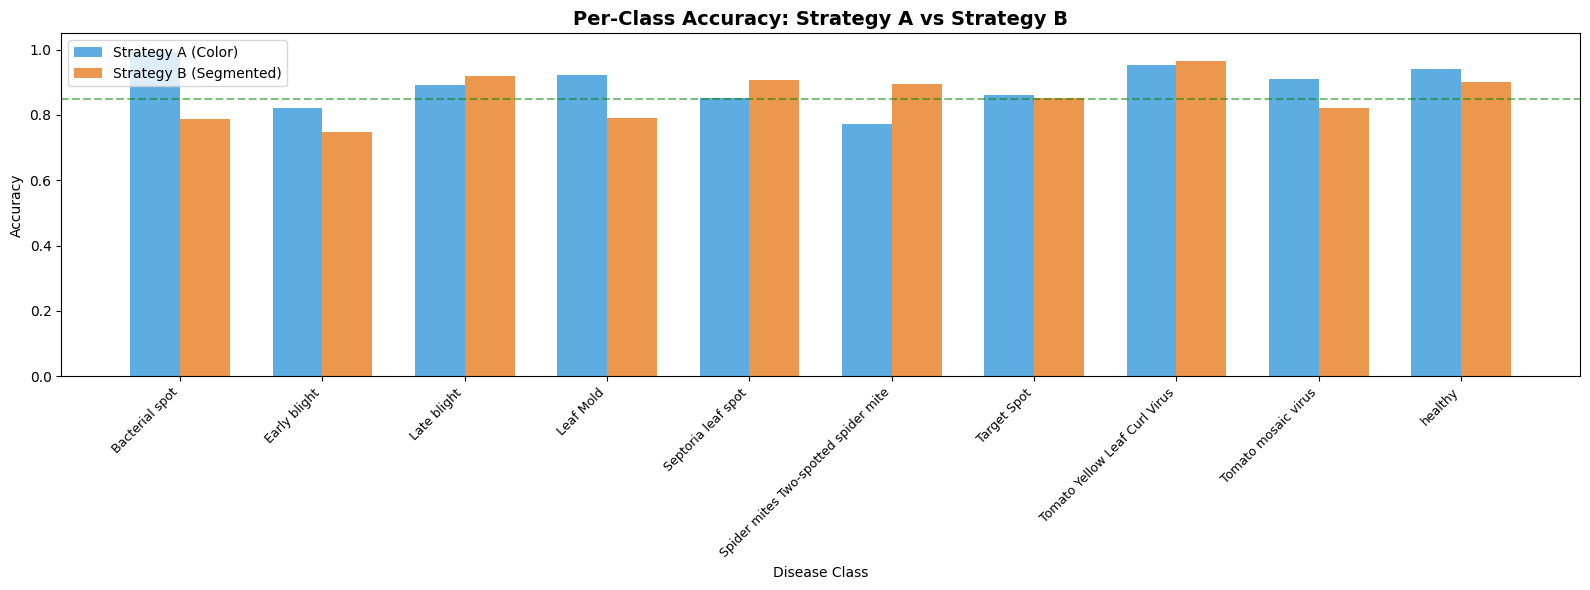


Class                                                A        B     Diff
--------------------------------------------------------------------
Bacterial spot                                   99.3%    78.7% 🔴 -20.6%
Early blight                                     82.0%    74.7% 🔴 -7.3%
Late blight                                      89.3%    92.0% 🟢 +2.7%
Leaf Mold                                        92.3%    79.0% 🔴 -13.3%
Septoria leaf spot                               85.3%    90.7% 🟢 +5.4%
Spider mites Two-spotted spider mite             77.3%    89.3% 🟢 +12.0%
Target Spot                                      86.0%    85.3% 🔴 -0.7%
Tomato Yellow Leaf Curl Virus                    95.3%    96.7% 🟢 +1.4%
Tomato mosaic virus                              91.1%    82.1% 🔴 -9.0%
healthy                                          94.0%    90.0% 🔴 -4.0%


In [9]:
# Strategy A per-class results (from your 03_evaluation.ipynb)
strategy_A = {
    'Bacterial spot'                        : 0.993,
    'Early blight'                          : 0.820,
    'Late blight'                           : 0.893,
    'Leaf Mold'                             : 0.923,
    'Septoria leaf spot'                    : 0.853,
    'Spider mites Two-spotted spider mite'  : 0.773,
    'Target Spot'                           : 0.860,
    'Tomato Yellow Leaf Curl Virus'         : 0.953,
    'Tomato mosaic virus'                   : 0.911,
    'healthy'                               : 0.940
}

strategy_B = dict(zip(class_names_short, per_class_accuracy))

# Plot side by side comparison
x = np.arange(len(class_names_short))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars_A = ax.bar(x - width/2, list(strategy_A.values()),
                width, label='Strategy A (Color)', color='#3498db', alpha=0.8)
bars_B = ax.bar(x + width/2, list(strategy_B.values()),
                width, label='Strategy B (Segmented)', color='#e67e22', alpha=0.8)

ax.set_xlabel('Disease Class')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy: Strategy A vs Strategy B',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names_short, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.5)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f"../outputs/comparison_A_vs_B.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Print difference table
print(f"\n{'Class':<45} {'A':>8} {'B':>8} {'Diff':>8}")
print("-" * 68)
for cls in class_names_short:
    a = strategy_A.get(cls, 0)
    b = strategy_B.get(cls, 0)
    diff = (b - a) * 100
    arrow = "🟢" if diff > 0 else "🔴"
    print(f"{cls:<45} {a:>8.1%} {b:>8.1%} {arrow} {diff:>+.1f}%")

In [11]:
results_path = r"D:\Development\8th Sem Project\TomatoClassification\outputs\results_summary.txt"

with open(results_path, 'a') as f:
    f.write(f"\nStrategy {STRATEGY} — Evaluation\n")
    f.write(f"  Test Accuracy    : {test_accuracy:.4f}\n")
    f.write(f"  Test Loss        : {test_loss:.4f}\n")
    f.write(f"  Classification Report:\n{report}\n")

print(f"✅ Evaluation results saved to: {results_path}")
print(f"\n📁 Outputs saved:")
print(f"   confusion_matrix_{STRATEGY}.png")
print(f"   per_class_accuracy_{STRATEGY}.png")
print(f"   comparison_A_vs_B.png")

✅ Evaluation results saved to: D:\Development\8th Sem Project\TomatoClassification\outputs\results_summary.txt

📁 Outputs saved:
   confusion_matrix_B_segmented.png
   per_class_accuracy_B_segmented.png
   comparison_A_vs_B.png
